In [34]:
# import libraries
from sklearn.datasets import make_regression
import pandas as pd
import numpy as np

import plotly.express as px
import plotly.graph_objects as go

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [5]:
X, y = make_regression(n_samples=100, n_features=2, n_informative=2, n_targets=1, noise=50)

In [6]:
df = pd.DataFrame(
    {
        'feature1': X[:,0],
        'feature2': X[:,1],
        'target': y
    }
)

# top-5 rows
df.head()

,feature1,feature2,target
0,0.013272,0.498754,87.699962
1,-0.788559,1.616460,-51.836857
2,1.302195,2.044702,175.346361
3,-0.039636,0.116300,-80.000940
4,-1.380121,0.708912,-182.260861


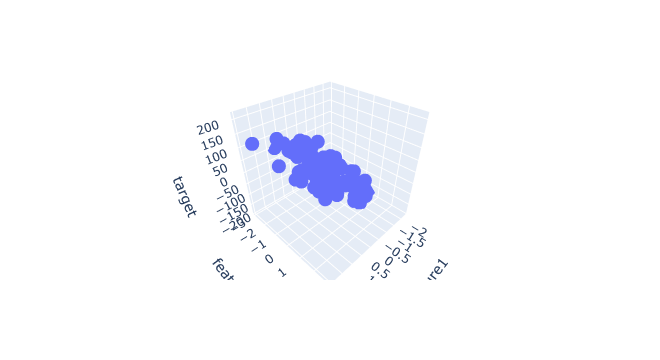

In [9]:
fig = px.scatter_3d(df, x='feature1', y='feature2', z='target')
fig.show()

In [12]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=3
)

In [13]:
from sklearn.linear_model import LinearRegression

# create an object of LinearRegression
lr = LinearRegression()

In [14]:
# fit the model into the data.
lr.fit(X_train, y_train )

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [16]:
# predict the values
y_pred = lr.predict(X_test)
print(y_pred)


[-209.51956239  -57.30170322   28.65428695  110.08118325  178.639447
  106.39364002  -37.68434815   88.95270763 -153.74206225  -62.90489053
    9.0845979    55.00115748  149.18888494   73.11542044  137.81372172
 -206.4806421   117.6382794    16.57100568  -41.27451923  -30.32875101]


In [22]:
from sklearn.metrics import root_mean_squared_error
# Multiple linear regression metric.
print('mean_absolute_error:',mean_absolute_error(y_pred, y_test))
print('mean_squared_error:',mean_squared_error(y_pred, y_test))
print('root_mean_squared_error:',root_mean_squared_error(y_pred, y_test))
print('r2_score:',r2_score(y_pred, y_test))
print('Ajusted_r2_score:',(1-((1-r2_score(y_pred, y_test))*(100-1))/(100-1-2)))

mean_absolute_error: 36.78775622118184
mean_squared_error: 1824.2282349570305
root_mean_squared_error: 42.71098494482457
r2_score: 0.851481650697262
Ajusted_r2_score: 0.84841941669102


In [37]:
x = np.linspace(-5, 5, 10)
y = np.linspace(-5, 5, 10)

xGrid, yGrid = np.meshgrid(x, y)
final = np.vstack((xGrid.ravel().reshape(1, 100), yGrid.ravel().reshape(1, 100))).T

z_final = lr.predict(final).reshape(10, 10)
z = z_final 

fig = px.scatter_3d(df, x='feature1', y='feature2', z='target')

fig = add_trace(go.Surface(x = x, y = y, z = z))

fig.show()

NameError: name 'add_trace' is not defined

In [33]:
lr.coef_, lr.intercept_

(array([92.01728947,  3.5473435 ]), np.float64(-2.2148286437063067))